# MERT embedding explorer & prediction-cache builder

This notebook does two things with the `ppsync` pipeline:

1. **Build the `.npz` prediction caches** for songs (the same artifact
   `ppsync-preprocess` produces and `ppsync-align` / `tools/benchmark.py`
   consume) — both for a single song and as a batch.
2. **Explore the MERT embeddings** inside a cache: self-similarity (song
   structure), per-slide prototype similarity (repeat ambiguity), a 2-D PCA
   projection, and the effect of contrastive normalization.

**Setup** — uses the project's Poetry environment (defined in the repo
`pyproject.toml`); the notebook extras live in the optional `notebooks` group:

```bash
poetry install --with notebooks      # ppsync + jupyterlab + matplotlib
poetry run jupyter lab notebooks/explore_mert_embeddings.ipynb
```


In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Resolve the repo root whether the notebook is launched from the repo root
# or from inside notebooks/, and make ppsync importable even without `pip -e`.
ROOT = Path.cwd()
ROOT = ROOT.parent if ROOT.name == "notebooks" else ROOT
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import torch
from ppsync.io import load_song_meta, load_manifest, load_audio
from ppsync.preprocess import preprocess_song, load_cache, sliding_window_embeddings
from ppsync.embed import load_model

device = ("cuda" if torch.cuda.is_available()
          else "mps" if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available()
          else "cpu")
print("repo root:", ROOT)
print("device:", device)


Matplotlib is building the font cache; this may take a moment.


repo root: /Users/das/propresenter-music
device: mps


## 1. Pick a song

Point `MANIFEST` at any ppsync manifest (artist + slides + `ref_audio`).  The
cache will be written beside it as `<artist>_<title>_cache.npz`.

In [2]:
MANIFEST = ROOT / "data/incubus/drive/incubus_drive_manifest.json"

meta = load_song_meta(MANIFEST)
out_npz = MANIFEST.parent / f"{meta['slug']}_cache.npz"
print(f"{meta['artist']} — {meta['song_id']}   [slug: {meta['slug']}]")
print("cache will be:", out_npz)


Incubus — Drive   [slug: incubus_drive]
cache will be: /Users/das/propresenter-music/data/incubus/drive/incubus_drive_cache.npz


## 2. Build the prediction cache (`.npz`)

This runs MERT over the reference audio: one forward pass per sliding 2 s
window at the configured stride, then contrastive-normalizes, pools per-slide
prototypes, and builds the HMM transition matrix — exactly what
`ppsync-preprocess` does.  First run downloads MERT (~370 MB) and takes a
couple of minutes on GPU.  Skipped automatically if the cache already exists.

In [3]:
if out_npz.exists():
    print("cache already exists, skipping build:", out_npz)
else:
    preprocess_song(manifest_path=MANIFEST, output_path=out_npz, device=device)


cache already exists, skipping build: /Users/das/propresenter-music/data/incubus/drive/incubus_drive_cache.npz


## 3. Load the cache and inspect

The cache is a plain `.npz`.  The embeddings (`ref_embs`, `slide_protos`) are
already L2-normalized after contrastive normalization, so a dot product is a
cosine similarity.

In [4]:
cache = load_cache(out_npz)
ref     = cache["ref_embs"]          # [N, D]  one row per 2s window
ts      = cache["ref_timestamps"]    # [N]     window right-edge time (s)
protos  = cache["slide_protos"]      # [S, D]  per-slide prototype
sids    = list(cache["slide_ids"])
t_refs  = cache["slide_t_refs"]      # [S]
t_stops = cache["slide_t_stops"]     # [S]

print(f"{cache['artist']} — {cache['song_id']}")
print(f"ref embeddings : {ref.shape}  (N windows x D dims)  stride {float(cache['stride_sec'])}s")
print(f"slides         : {len(sids)}   prototypes {protos.shape}")
print(f"L2 norm (~1?)  : mean {np.linalg.norm(ref, axis=1).mean():.4f}")
print(f"duration       : {float(cache['song_duration']):.1f}s   MERT layer {int(cache['mert_layer'])}")


Incubus — Drive
ref embeddings : (2319, 768)  (N windows x D dims)  stride 0.10000000149011612s
slides         : 15   prototypes (15, 768)
L2 norm (~1?)  : mean 1.0000
duration       : 233.9s   MERT layer 7


## 4. Self-similarity matrix — song structure

Cosine similarity of every window against every other.  The bright diagonal is
each window matching itself; **off-diagonal bright stripes are repeats** (a
chorus that recurs lights up against its earlier occurrences).  Cyan lines mark
slide boundaries.

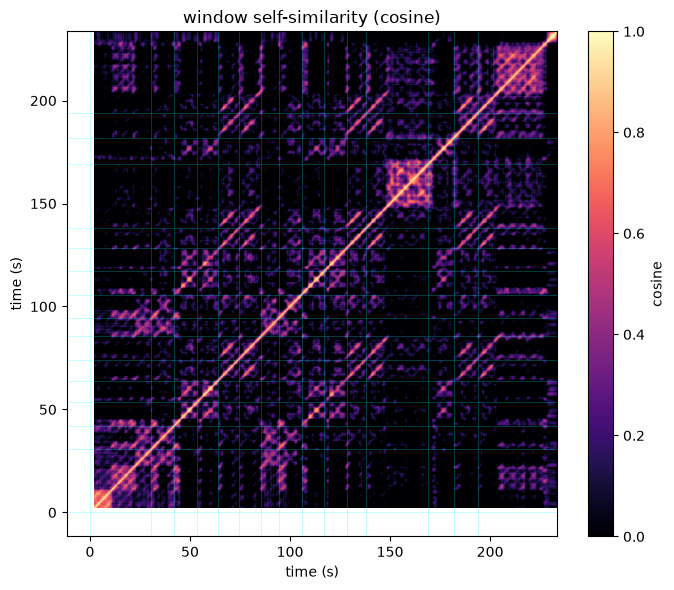

In [5]:
# subsample to keep the heatmap a manageable size
step = max(1, ref.shape[0] // 600)
R, Rt = ref[::step], ts[::step]
S = R @ R.T                      # cosine (rows are L2-normalized)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(S, origin="lower", extent=[Rt[0], Rt[-1], Rt[0], Rt[-1]],
               cmap="magma", vmin=0, vmax=1, aspect="auto")
for t in t_refs:
    ax.axvline(t, color="cyan", lw=0.4, alpha=0.4)
    ax.axhline(t, color="cyan", lw=0.4, alpha=0.4)
ax.set(xlabel="time (s)", ylabel="time (s)", title="window self-similarity (cosine)")
fig.colorbar(im, ax=ax, label="cosine"); plt.tight_layout(); plt.show()


## 5. Per-slide prototype similarity — repeat ambiguity

Each slide's prototype against every other.  High off-diagonal values are
slides that *look alike* to the matcher — repeated choruses/refrains.  This is
exactly the ambiguity the initial-lock and jump-guard logic defends against.

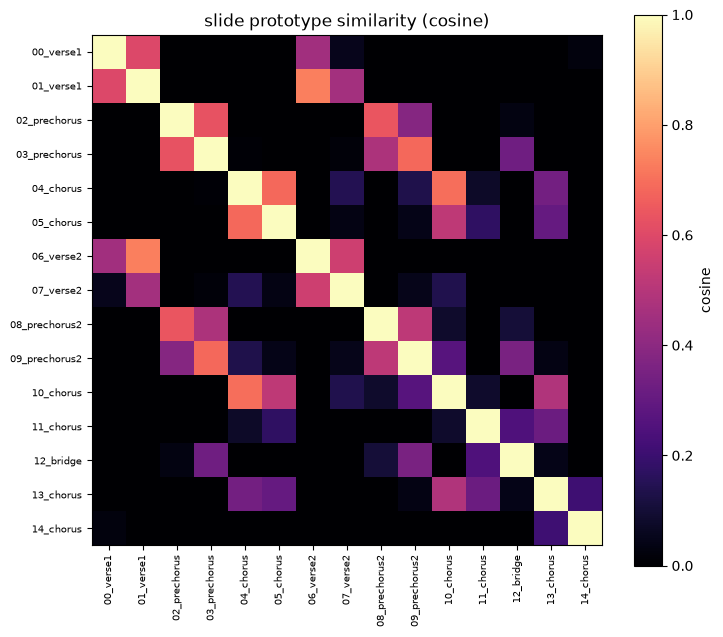

In [6]:
P = protos @ protos.T
fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(P, cmap="magma", vmin=0, vmax=1)
ax.set_xticks(range(len(sids))); ax.set_xticklabels(sids, rotation=90, fontsize=7)
ax.set_yticks(range(len(sids))); ax.set_yticklabels(sids, fontsize=7)
ax.set_title("slide prototype similarity (cosine)")
fig.colorbar(im, ax=ax, label="cosine"); plt.tight_layout(); plt.show()


## 6. 2-D projection (PCA) of the windows

Project the embeddings onto their top-2 principal directions (plain NumPy SVD,
no scikit-learn) and color each window by the slide it falls in.  Sections that
sound distinct separate into clusters; repeats overlap.

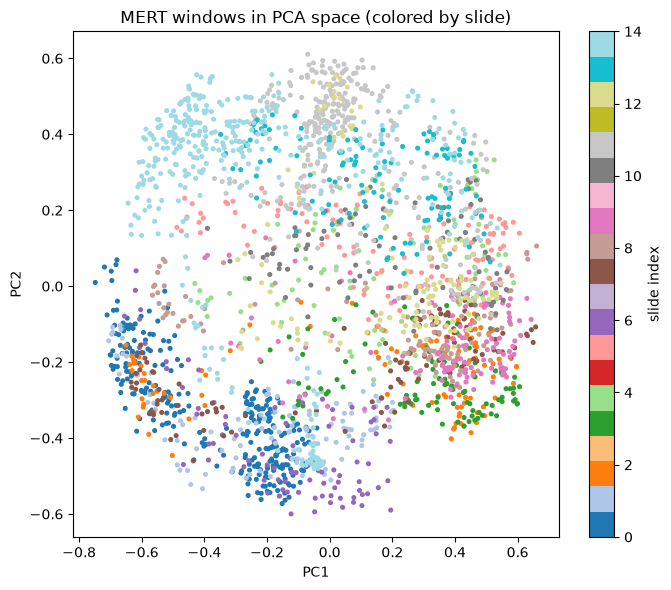

In [13]:
slide_of = np.clip(np.searchsorted(t_refs, ts, side="right") - 1, 0, len(sids) - 1)
X = ref - ref.mean(0, keepdims=True)
_, _, Vt = np.linalg.svd(X, full_matrices=False)
proj = X @ Vt[:2].T

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(proj[:, 0], proj[:, 1], c=slide_of, cmap="tab20", s=7)
ax.set(xlabel="PC1", ylabel="PC2", title="MERT windows in PCA space (colored by slide)")
fig.colorbar(sc, ax=ax, label="slide index"); plt.tight_layout(); plt.show()


## 7. Contrastive normalization — before vs. after (optional)

`apply_contrastive` subtracts the song-level mean then L2-normalizes, removing
the dominant "sounds like music" direction that makes *every* section score
~0.9 cosine.  This cell re-runs MERT to get the **raw** (un-normalized) windows
and compares their self-similarity to the normalized ones in the cache.  It
loads the model and re-embeds the song, so it is slow — set the flag to run.

/Users/das/propresenter-music/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Sliding windows: 100%|████████████████████| 145/145 [01:16<00:00,  1.88batch/s]


mean off-diagonal cosine  raw: 0.888   contrastive: 0.003


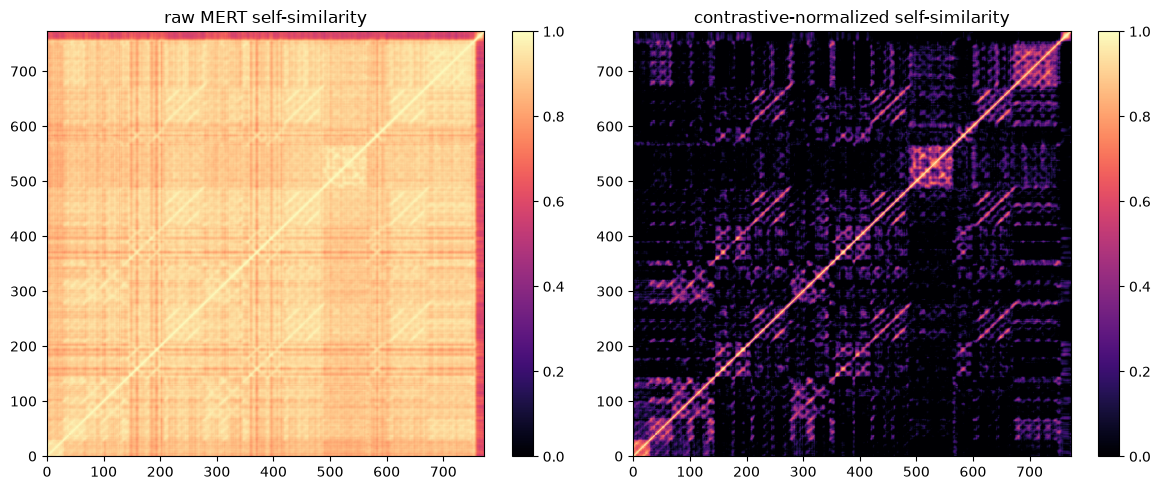

In [9]:
RUN_RAW_COMPARISON = True  # set True to re-run MERT for the raw embeddings

if RUN_RAW_COMPARISON:
    audio_path, _ = load_manifest(MANIFEST)
    wav = load_audio(audio_path)
    processor, model = load_model(device, truncate_after_layer=int(cache["mert_layer"]))
    raw, _ = sliding_window_embeddings(
        wav, model, processor, device,
        stride_sec=float(cache["stride_sec"]), mert_layer=int(cache["mert_layer"]),
    )
    raw = raw.numpy()
    rawn = raw / (np.linalg.norm(raw, axis=1, keepdims=True) + 1e-9)

    st = max(1, raw.shape[0] // 600)
    S_raw  = rawn[::st] @ rawn[::st].T
    S_norm = ref[::max(1, ref.shape[0] // 600)] @ ref[::max(1, ref.shape[0] // 600)].T
    print(f"mean off-diagonal cosine  raw: {S_raw.mean():.3f}   contrastive: {S_norm.mean():.3f}")

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    for a, M, ttl in ((axs[0], S_raw, "raw MERT"), (axs[1], S_norm, "contrastive-normalized")):
        im = a.imshow(M, origin="lower", cmap="magma", vmin=0, vmax=1, aspect="auto")
        a.set_title(ttl + " self-similarity"); fig.colorbar(im, ax=a)
    plt.tight_layout(); plt.show()
else:
    print("set RUN_RAW_COMPARISON = True to run (re-embeds the song with MERT).")


## 8. Batch-build caches for many songs

Loop over a list of manifests and build every prediction cache in one go.  Add
your songs to `MANIFESTS`; each writes `<slug>_cache.npz` beside its manifest
(skipped if it already exists).

In [10]:
MANIFESTS = [
    ROOT / "data/incubus/drive/incubus_drive_manifest.json",
    ROOT / "data/forrest_frank/your_way_is_better/forrest_frank_your_way_is_better_manifest.json",
]

for m in MANIFESTS:
    if not m.exists():
        print("missing manifest, skipping:", m); continue
    mt = load_song_meta(m)
    out = m.parent / f"{mt['slug']}_cache.npz"
    if out.exists():
        print("skip (exists):", out.name); continue
    print(f"building {mt['artist']} — {mt['song_id']} ...")
    preprocess_song(manifest_path=m, output_path=out, device=device)
print("done — these .npz files are what ppsync-align / ppsync-eval / benchmark.py load.")


skip (exists): incubus_drive_cache.npz
skip (exists): forrest_frank_your_way_is_better_cache.npz
done — these .npz files are what ppsync-align / ppsync-eval / benchmark.py load.
